# Numerical Integration: Simpson’s 1/3 Rule
---
## Introduction
Simpson’s 1/3 Rule is a higher‑order numerical integration method.

It approximates the function using quadratic polynomials over subintervals.

For a function f(x) over [a, b], divide the interval into n equal parts,
where n must be EVEN.

$$h = \frac{b-a}{n}$$

### Simpson’s 1/3 Rule Formula

$$\int_a^b f(x) dx \approx \frac{h}{3} \left[
f(x_0) + 4\sum_{odd} f(x_i) + 2\sum_{even} f(x_i) + f(x_n)
\right]$$

Odd indexed terms get weight 4.
Even indexed terms get weight 2.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simpsons_rule(f, a, b, n):
    if n % 2 != 0:
        raise ValueError('n must be even for Simpson’s 1/3 Rule')
    
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)

    S = y[0] + y[n]
    S += 4 * np.sum(y[1:n:2])
    S += 2 * np.sum(y[2:n-1:2])

    return (h/3) * S

## Example 1
Approximate:
$$\int_0^1 e^{-x^2} dx$$

In [3]:
def f(x):
    return np.exp(-x**2)

a = 0
b = 1
n = 6  # must be even

approx = simpsons_rule(f, a, b, n)
approx

0.746830391489345

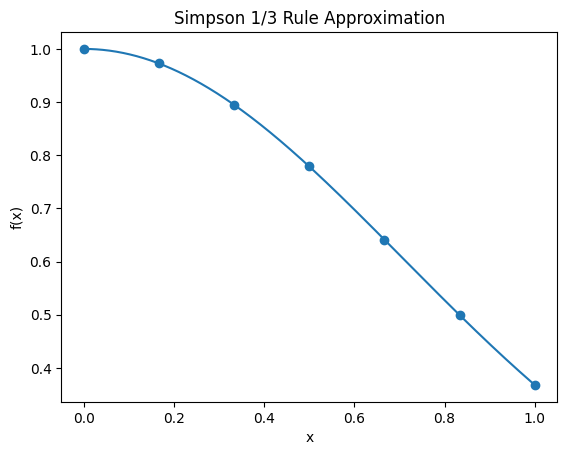

In [4]:
def plot_simpson(f, a, b, n):
    x = np.linspace(a, b, 1000)
    y = f(x)
    xi = np.linspace(a, b, n+1)
    yi = f(xi)

    plt.figure()
    plt.plot(x, y)
    plt.scatter(xi, yi)
    plt.title('Simpson 1/3 Rule Approximation')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.show()

plot_simpson(f, a, b, n)

## Example 2
Approximate:
$$\int_1^3 x^2 dx$$
Exact value = 26/3

In [5]:
def f2(x):
    return x**2

a = 1
b = 3
n = 4

approx2 = simpsons_rule(f2, a, b, n)
exact = 26/3

approx2, exact

(8.666666666666666, 8.666666666666666)

In [7]:
error = abs(exact - approx2)
error

0.0

## Convergence Study

In [8]:
for n in [2,4,8,16,32]:
    approx = simpsons_rule(f2, 1, 3, n)
    print('n =', n, 'Approximation =', approx)

n = 2 Approximation = 8.666666666666666
n = 4 Approximation = 8.666666666666666
n = 8 Approximation = 8.666666666666666
n = 16 Approximation = 8.666666666666666
n = 32 Approximation = 8.666666666666666
